In [2]:
pip install pandas scikit-learn matplotlib seaborn scikit-surprise

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 3.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


In [1]:
df = pd.read_csv('movies.csv')  # replace with your actual filename
print(df.shape)
print(df.head())

NameError: name 'pd' is not defined

In [2]:
df = pd.read_csv('C:\Users\user\Downloads.csv')  # replace with your actual filename
print(df.shape)
print(df.head())

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (99456204.py, line 1)

In [3]:
import pandas as pd
df = pd.read_csv(r'C:\Users\user\Downloads.csv')  # replace with your actual filename
print(df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\user\\Downloads.csv'

In [4]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv(r"C:\Users\user\Downloads\ml-latest-small\movies.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head())

(9742, 3)
['movieId', 'title', 'genres']
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [5]:
# Clean genres column (replace | with space)
df['genres'] = df['genres'].str.replace('|', ' ', regex=False)
df['genres'] = df['genres'].str.replace('(no genres listed)', '', regex=False)

print(df.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure Animation Children Comedy Fantasy  
1                   Adventure Children Fantasy  
2                               Comedy Romance  
3                         Comedy Drama Romance  
4                                       Comedy  


In [6]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['genres'])
print("Matrix shape:", tfidf_matrix.shape)

Matrix shape: (9742, 21)


In [7]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (9742, 9742)


In [8]:
def recommend(movie_title):
    idx = df[df['title'] == movie_title].index[0]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]
    print(f"\nMovies similar to '{movie_title}':")
    for i, score in scores:
        print(f"  - {df['title'].iloc[i]}")

# Test it!
recommend("Toy Story (1995)")


Movies similar to 'Toy Story (1995)':
  - Antz (1998)
  - Toy Story 2 (1999)
  - Adventures of Rocky and Bullwinkle, The (2000)
  - Emperor's New Groove, The (2000)
  - Monsters, Inc. (2001)


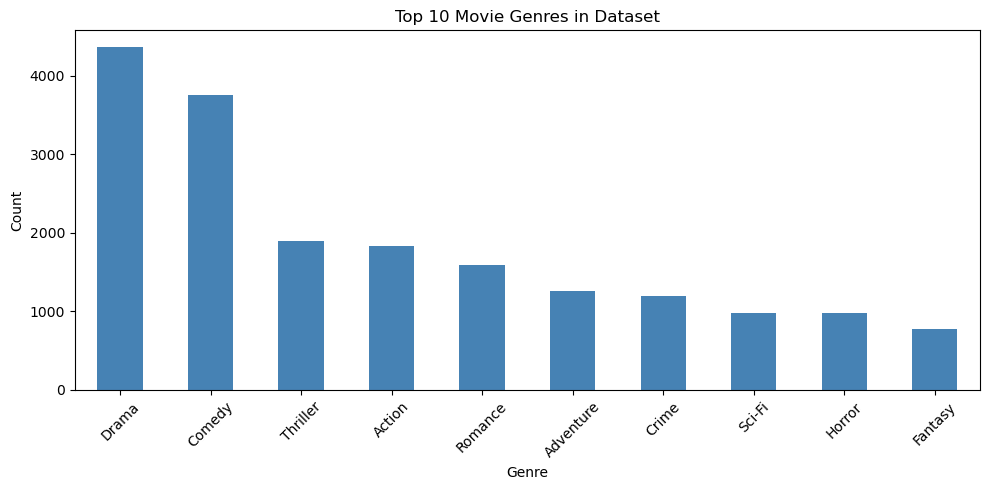

In [9]:
import matplotlib.pyplot as plt

# Show genre distribution
genre_list = []
for genres in df['genres']:
    for g in genres.split():
        genre_list.append(g)

genre_counts = pd.Series(genre_list).value_counts().head(10)

plt.figure(figsize=(10, 5))
genre_counts.plot(kind='bar', color='steelblue')
plt.title('Top 10 Movie Genres in Dataset')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()